## Environment layer processing
**Date:** 2025-09-26    
**Updated:** 2026-05-07     
**Author:** Winnie Liao     

Raster processing steps reference [Introduction to Python GIS](https://automating-gis-processes.github.io/CSC/) <br>
<br>
Update (2026-02-10): Keep cells initially flagged as outliers, as they likely reflect valid values. Saturation masks out true bright spots (eg. airports, downtown) <br>
Update (2026-02-22): Calculate environmental layers based on defined boundaries <br>
Update (2026-03-27): Compute multi-resolution NTL (100m grid, moving window) <br>
Update (2026-05-07): Compute multi-resolution building density (100m grid, 500m and 1000m moving windows)

In [1]:
# packages

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
import xml.etree.ElementTree as ET
from rasterio import Affine
from rasterio.io import MemoryFile
from rasterio.plot import show, show_hist
from rasterio.features import rasterize, shapes
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_geom
from rasterio.mask import mask
from rasterio.transform import from_origin, rowcol
from rasterio.enums import Resampling
from rasterstats import zonal_stats
from shapely.geometry import box
from scipy.spatial import cKDTree

In [2]:
# paths
path_env = "../data/raw/envir"
out_path = "../data/processed"
path_collision = "../data/processed"

landcover = os.path.join(path_env, "landcover_chicagoregional_mosaic.tif")
ntl = os.path.join(path_env, "KX10_GIU_20250916_W89.00_N41.66_202500097282_L4A_B_LH.tif")
grid_100m = os.path.join(path_env, "grid_100m_outerbound.shp") # note: this grid_100m differs from the one in the "calculate ntl to 100m grids" section

v_100m_bound = os.path.join(path_env, "grid_100m_outerbound.shp")

collision = "data_only-coordinates_2010-2024_building-check-yes_20260201.csv"
r_col = os.path.join(path_collision, collision)


### 100m outerbound

In [3]:
# # check if vector 100m bound has UIDs
# # no

# # Read fishnet shapefile
# gdf = gpd.read_file(v_100m_bound)

# # We already know the ID field is "uid"
# uid_field = "uid"

# # Print columns to confirm
# print("Shapefile fields:", list(gdf.columns))
# print(gdf[[uid_field]].head())

In [4]:
# # Output paths
# out_gpkg = os.path.join(out_path, "grid_100m_outerbound.gpkg")  # recommended output
# layer_name = "grid_100m_outerbound"

# # Load shapefile
# gdf = gpd.read_file(v_100m_bound)

# # Create UID field (1,2,3,...,N) - int64
# gdf["uid"] = np.arange(1, len(gdf) + 1, dtype=np.int64)

# # check
# print("UID field added. First rows:")
# print(gdf.head())

# # Save to GeoPackage
# gdf.to_file(out_gpkg, driver="GPKG", layer=layer_name)

# print(f"UID added and saved to: {out_gpkg}")


In [5]:
# # Rasterize the 100m outerbound vector

# gdf = gpd.read_file(v_100m_bound)
# res = 100

# # Ensure the vector has a CRS
# if gdf.crs is None:
#     raise ValueError("Vector has no CRS. Please define or set a CRS before rasterizing.")
# else:
#     print(gdf.crs)

In [6]:
# # Compute raster geometry of the 100m outerbound
# # already saved

# minx, miny, maxx, maxy = gdf.total_bounds
# width = int(np.ceil((maxx - minx) / res))
# height = int(np.ceil((maxy - miny) / res))
# transform = from_origin(minx, maxy, res, res)

# # Rasterize: burn value 1 inside geometries, 0 elsewhere
# shapes = [(geom, 1) for geom in gdf.geometry if geom is not None and not geom.is_empty]
# data = rasterize(
#     shapes=shapes,
#     out_shape=(height, width),
#     transform=transform,
#     fill=0,
#     all_touched=True,
#     dtype="float32"
# )

# # Write the raster directly to out_path
# profile = {
#     "driver": "GTiff",
#     "height": height,
#     "width": width,
#     "count": 1,
#     "dtype": "float32",
#     "crs": gdf.crs,
#     "transform": transform,
#     "nodata": 0.0,
#     "compress": "lzw"
# }

# # output
# out_fp = os.path.join(out_path, "grid_100m_outerbound.tif")

# with rio.open(out_fp, "w", **profile) as dst:
#     dst.write(data.astype("float32"), 1)

# print("Saved:", out_fp)

In [7]:
# # Compute raster geometry of the 100m outerbound
# # saved already
# # assign UID to each grid
# # Build output raster geometry (extent, shape, transform)
# minx, miny, maxx, maxy = gdf.total_bounds
# width  = int(np.ceil((maxx - minx) / res))
# height = int(np.ceil((maxy - miny) / res))
# transform = from_origin(minx, maxy, res, res)

# # Use or create a UID field
# uid_field = None
# for cand in ("uid", "UID", "id", "ID", "grid_id", "GRID_ID"):
#     if cand in gdf.columns:
#         uid_field = cand
#         break
# if uid_field is None:
#     # Create sequential UIDs starting from 1
#     gdf = gdf.copy()
#     gdf["uid"] = np.arange(1, len(gdf) + 1, dtype=np.int64)
#     uid_field = "uid"

# # Prepare (geometry, uid) tuples; skip empty geometries
# shapes = [
#     (geom, int(uid))
#     for geom, uid in zip(gdf.geometry, gdf[uid_field])
#     if geom is not None and not geom.is_empty
# ]

# # Rasterize: burn UID into cells; background = 0 (nodata-like)
# uid_raster = rasterize(
#     shapes=shapes,
#     out_shape=(height, width),
#     transform=transform,
#     fill=0,
#     all_touched=True,
#     dtype="float32",
# )

# # Write GeoTIFF (overwrite the target path)
# out_fp = "/u/shuyueh2/winnie/chicago-bird-collision/data/processed/grid_100m_outerbound.tif"
# profile = {
#     "driver": "GTiff",
#     "height": height,
#     "width": width,
#     "count": 1,
#     "dtype": "float32",
#     "crs": gdf.crs,
#     "transform": transform,
#     "nodata": 0,
#     "compress": "lzw",
# }

# with rio.open(out_fp, "w", **profile) as dst:
#     dst.write(uid_raster, 1)

# print("Saved UID raster:", out_fp)


In [8]:
# # check
# with rio.open("../data/processed/grid_100m_outerbound.tif") as src:
#     uid_arr = src.read(1)
#     print("Raster shape:", uid_arr.shape)
#     print("Unique values (sample):", np.unique(uid_arr)[:20])

In [9]:
# # Quicklook plot for the 100m outerbound raster

# max_px = 1_500_000  # target pixels for quicklook

# with rio.open(out_fp) as src:
#     h, w = src.height, src.width
#     total = w * h

#     # Compute scale so that w*h ~ max_px
#     scale = 1.0 if total <= max_px else float(np.sqrt(max_px / float(total)))
#     new_h = max(1, int(np.ceil(h * scale)))
#     new_w = max(1, int(np.ceil(w * scale)))

#     # Read downsampled band 1; for categorical masks keep nearest
#     arr = src.read(1, out_shape=(new_h, new_w), resampling=Resampling.nearest)
#     nodata = src.nodata
#     if (nodata is not None) and (not np.isnan(nodata)):
#         arr = np.ma.masked_equal(arr, nodata)

#     bounds = src.bounds

# # Plot with geographic extent
# aspect = new_w / new_h if new_h != 0 else 1.0
# plt.figure(figsize=(8, 8 / aspect))
# im = plt.imshow(
#     arr,
#     extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
#     origin="upper",
#     interpolation="nearest"
# )
# plt.title(f"Quicklook ({new_w}x{new_h}) from {w}x{h}")
# plt.xlabel("X")
# plt.ylabel("Y")
# plt.colorbar(im, shrink=0.8, label="Value")
# plt.tight_layout()
# plt.show()

### Nighttime light to radiance and reprojection

In [ ]:
# Data is KX10_GIU_20250916_W89.00_N41.66_202500097282_L4A_B_LH.tif
# check band & CRS
# multiple bands in the data

ntl = rio.open(ntl)
print(ntl.count, ntl.descriptions)
print(ntl.crs.to_epsg())

3 ('PL', 'PH', 'HDR')
32616


In [ ]:
# Check Band3 shape
ntl = os.path.join(path_env, "KX10_GIU_20250916_W89.00_N41.66_202500097282_L4A_B_LH.tif") # reread ntl as path

with rio.open(ntl) as src:
    # Extract the third band
    band3 = src.read(3)

# Print the shape of the band array
print("Band 3 shape:", band3.shape)

Band 3 shape: (37272, 22376)


In [ ]:
# # save raster with only band 3 to disk
# # finished
# ntl_band3 = os.path.join(out_path, "ntl_band3.tif")

# with rio.open(
#     ntl_band3,
#     "w",
#     driver="GTiff",
#     height=band3.shape[0],
#     width=band3.shape[1],
#     count=1,
#     dtype=band3.dtype,
#     crs=src.crs,
#     transform=src.transform,
# ) as dst:
#     dst.write(band3, 1)

# # check band layers
# # should be 1
# a = rio.open("../data/processed/ntl_band3.tif")
# a.count

In [13]:
# # reproject
# # finished
# dst_crs = "EPSG:26916"; out = os.path.join(out_path, "ntl_band3_26916.tif")
# with rio.open("../data/processed/ntl_band3.tif") as src:
#     transform, width, height = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
#     profile = src.profile; profile.update(crs=dst_crs, transform=transform, width=width, height=height)
#     with rio.open(out, "w", **profile) as dst:
#         for i in range(1, src.count + 1):
#             reproject(rio.band(src, i), rio.band(dst, i), src_transform=src.transform, src_crs=src.crs, dst_transform=transform, dst_crs=dst_crs, resampling=Resampling.bilinear)

In [ ]:
# Digital numbers (DN) to radiance
# paths

ntl_file = os.path.join(out_path, "ntl_band3_26916.tif")
calib_xml = os.path.join(path_env, "KX10_GIU_20250916_W89.00_N41.66_202500097282_L4A.calib.xml")
out_file = os.path.join(out_path, "ntl_band3_26916_radiance.tif")

# Read Gain & Bias from XML
with open(calib_xml, 'r', encoding='gb2312') as f:
    xml_data = f.read()
root = ET.fromstring(xml_data)

# Parse GIU section for PL/PH (HDR uses both, average their radiance)
gain_pl = float(root.findtext(".//RADIANCE_GAIN_BAND_PL"))
bias_pl = float(root.findtext(".//RADIANCE_BIAS_BAND_PL"))
gain_ph = float(root.findtext(".//RADIANCE_GAIN_BAND_PH"))
bias_ph = float(root.findtext(".//RADIANCE_BIAS_BAND_PH"))

print(f"Gain/Bias PL: {gain_pl}, {bias_pl}")
print(f"Gain/Bias PH: {gain_ph}, {bias_ph}")

# Read DN GeoTIFF
with rio.open(ntl_file) as src:
    profile = src.profile
    dn = src.read(1).astype("float32")

# After checking with Jorge, I noticed that saturation masks out true bright spots (eg. airports, downtown)
# comment out saturation masking
# # Add Saturation Masking
# # 12-bit data -> valid DN 0–4095
# saturation_threshold = 4090
# saturated_mask = dn >= saturation_threshold

# # Replace saturated DN with NaN
# dn[saturated_mask] = np.nan

# Convert DN to Radiance
# Formula: L = 0.5*(DN*Gain_PL + Bias_PL) + 0.5*(DN*Gain_PH + Bias_PH)
radiance = 0.5 * (dn * gain_pl + bias_pl) + 0.5 * (dn * gain_ph + bias_ph)

# Save as new GeoTIFF
profile.update(dtype=rio.float32)

with rio.open(out_file, "w", **profile) as dst:
    dst.write(radiance.astype("float32"), 1)

print(f"Radiance file saved to: {out_file}")

Gain/Bias PL: 6.74154e-05, 1.67808e-05
Gain/Bias PH: 6.43698e-05, 1.83897e-05
Radiance file saved to: ../data/processed/ntl_band3_26916_radiance.tif


In [ ]:
# Change ntl GeoTIFF to log scale

# Input and output file paths
in_file = "../data/processed/ntl_band3_26916_radiance.tif"
out_file = "../data/processed/ntl_band3_26916_radiance_log10.tif"

# Read the raster data
with rio.open(in_file) as src:
    band = src.read(1).astype("float32")
    profile = src.profile

# Handle invalid values
# Log transformation is undefined for zero or negative values
band[band <= 0] = np.nan

# Apply log10 transformation
log_band = np.log10(band)

# Update data type in metadata
profile.update(dtype="float32")

# Write the transformed raster to a new file
with rio.open(out_file, "w", **profile) as dst:
    dst.write(log_band, 1)

print("Saved:", out_file)

Saved: ../data/processed/ntl_band3_26916_radiance_log10.tif


In [ ]:
# Stats for ntl band 3 after DN -> radiance
# linear scale

file = "../data/processed/ntl_band3_26916_radiance.tif"

with rio.open(file) as src:
    band = src.read(1).astype("float32")

valid = band[~np.isnan(band)]

print("Min:", np.min(valid))
print("Mean:", np.mean(valid))
print("Median:", np.median(valid))
print("Max:", np.max(valid))
print("Q25:", np.quantile(valid, 0.25))
print("Q75:", np.quantile(valid, 0.75))
print("Q90:", np.quantile(valid, 0.90))
print("Q97:", np.quantile(valid, 0.97))

plt.figure(figsize=(6,4))
plt.hist(valid, bins=200, color='gray', alpha=0.7)
plt.xlabel("Radiance (W·m⁻²·sr⁻¹·μm⁻¹)")
plt.ylabel("Pixel count")
plt.title("Radiance Distribution - SDGSAT-1 GIU HDR")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()

Min: 1.758525e-05
Mean: 0.0001234902
Median: 8.347785e-05
Max: 0.26984778
Q25: 1.758525e-05
Q75: 8.347785e-05


KeyboardInterrupt: 

Min: -4.7548513
Mean: -4.269321
Median: -4.0784287
Max: -0.56888115
Q25: -4.7548513
Q75: -4.0784287
Q90: -4.0784287
Q97: -3.6670306


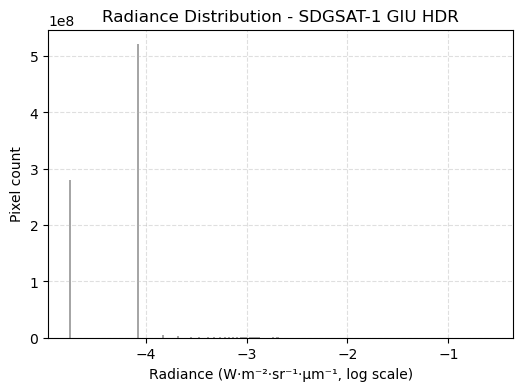

In [ ]:
# Stats for ntl band 3 after DN -> radiance
# log scale

file = "../data/processed/ntl_band3_26916_radiance_log10.tif"

with rio.open(file) as src:
    band = src.read(1).astype("float32")

valid = band[~np.isnan(band)]

print("Min:", np.min(valid))
print("Mean:", np.mean(valid))
print("Median:", np.median(valid))
print("Max:", np.max(valid))
print("Q25:", np.quantile(valid, 0.25))
print("Q75:", np.quantile(valid, 0.75))
print("Q90:", np.quantile(valid, 0.90))
print("Q97:", np.quantile(valid, 0.97))

plt.figure(figsize=(6,4))
plt.hist(valid, bins=200, color='gray', alpha=0.7)
plt.xlabel("Radiance (W·m⁻²·sr⁻¹·μm⁻¹, log scale)")
plt.ylabel("Pixel count")
plt.title("Radiance Distribution - SDGSAT-1 GIU HDR")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()

In [ ]:
# show brighter parts
plt.hist(valid[valid > 1e-4], bins=200, color='gray', alpha=0.7)
plt.xscale('log')
plt.xlabel("Radiance > 1e-4 (W·m⁻²·sr⁻¹·μm⁻¹)")
plt.ylabel("Pixel count")
plt.title("Bright-tail Distribution - SDGSAT-1 GIU HDR")
plt.show()

In [ ]:
# check crs

file = "../data/processed/ntl_band3_26916_radiance.tif"

with rio.open(file) as src:
    print(src.crs)

EPSG:26916


### Calculate NTL to 100m Grids

In [3]:
# load pre-defined functions
import sys
sys.path.append("../src")

from core import generate_effort_based_boundary, bias_bgp_from_vector

In [4]:
# Collision data
col = pd.read_csv(r_col)

In [5]:
# Study boundary - cell size = 1000 m, min point = 50
grid_filtered = generate_effort_based_boundary(
    df=col,
    lat_min=41.0,
    lat_max=43.0,
    lon_min=-89.0,
    lon_max=-87.0,
    cell_size=1000,
    min_points=50,
    plot=False,
)

Cells with > 50 points: 52
Total points in those cells: 79426


In [6]:
# Get total bounds of effort-based boundary grid
minx, miny, maxx, maxy = grid_filtered.total_bounds

cell_size = 100  # 100m grid

# Generate fishnet
x_coords = np.arange(minx, maxx, cell_size)
y_coords = np.arange(miny, maxy, cell_size)

polygons = []

for x in x_coords:
    for y in y_coords:
        polygons.append(box(x, y, x + cell_size, y + cell_size))

grid_100m = gpd.GeoDataFrame(
    {"geometry": polygons},
    crs=grid_filtered.crs
)

print("Total raw 100m cells:", len(grid_100m))

Total raw 100m cells: 172200


In [7]:
# Keep fishnet to only within boundaries
grid_100m = gpd.overlay(grid_100m, grid_filtered, how="intersection")

print("100m cells inside boundary:", len(grid_100m))

100m cells inside boundary: 5200


/u/shuyueh2/.conda/envs/chbico/lib/python3.13/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 2240 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [ ]:
# # check if geopandas intersection cut 100 m cells
# # Result: All cells are perfect 100m × 100m squares.
# grid_100m["area_m2"] = grid_100m.geometry.area

# expected_area = 100 * 100  # 100m × 100m = 10000 m²

# print("Expected area per cell:", expected_area)

# print("\nArea statistics:")
# print(grid_100m["area_m2"].describe())

# irregular = grid_100m[grid_100m["area_m2"] != expected_area]

# print("\nNumber of irregular (cut) cells:", len(irregular))

# if len(irregular) > 0:
#     print("Some cells were cut by boundary.")
# else:
#     print("All cells are perfect 100m × 100m squares.")

In [8]:
# Path
ntl_path = os.path.join(out_path, "ntl_band3_26916_radiance.tif")

# Calculate zonal mean
stats = zonal_stats(
    grid_100m,
    ntl_path,
    stats="mean",
    nodata=-9999
)

grid_100m["ntl_mean"] = [s["mean"] for s in stats]

grid_100m["ntl_mean"].describe()

KeyboardInterrupt: 

In [ ]:
# log scale
# Path
ntl_path = os.path.join(out_path, "ntl_band3_26916_radiance_log10.tif")

# Calculate zonal mean
stats = zonal_stats(
    grid_100m,
    ntl_path,
    stats="mean",
    nodata=-9999
)

grid_100m["ntl_mean"] = [s["mean"] for s in stats]

grid_100m["ntl_mean"].describe()

count    5200.000000
mean       -3.056945
std         0.576379
min        -4.078429
25%        -3.467893
50%        -2.989546
75%        -2.611934
max        -0.985481
Name: ntl_mean, dtype: float64

In [ ]:
# # visualize
# fig, ax = plt.subplots(figsize=(8, 8))

# grid_100m.plot(
#     column="ntl_mean",
#     cmap="viridis",
#     legend=True,
#     ax=ax
# )

# ax.set_title("Mean Nighttime Light Radiance (100m grid)")
# ax.set_xlabel("Easting (m)")
# ax.set_ylabel("Northing (m)")
# ax.set_aspect("equal")

# plt.show()

In [ ]:
# Output path
out_raster = "../data/processed/grid_100m_ntl_mean.tif"

# Extract centroid coordinates
grid_100m["x"] = grid_100m.geometry.centroid.x
grid_100m["y"] = grid_100m.geometry.centroid.y

cell_size = 100

# Define raster extent
minx, miny, maxx, maxy = grid_100m.total_bounds

width = int((maxx - minx) / cell_size)
height = int((maxy - miny) / cell_size)

transform = from_origin(minx, maxy, cell_size, cell_size)

# Create empty array
raster_array = np.full((height, width), np.nan, dtype="float32")

# Fill raster values
for _, row in grid_100m.iterrows():
    col = int((row["x"] - minx) / cell_size)
    row_idx = int((maxy - row["y"]) / cell_size)
    raster_array[row_idx, col] = row["ntl_mean"]

# Write GeoTIFF
with rio.open(
    out_raster,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=grid_100m.crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(raster_array, 1)

print("Saved:", out_raster)

Saved: ../data/processed/grid_100m_ntl_mean.tif


In [ ]:
# log scale
# Output path
out_raster = "../data/processed/grid_100m_ntl_mean_log10.tif"

# Extract centroid coordinates
grid_100m["x"] = grid_100m.geometry.centroid.x
grid_100m["y"] = grid_100m.geometry.centroid.y

cell_size = 100

# Define raster extent
minx, miny, maxx, maxy = grid_100m.total_bounds

width = int((maxx - minx) / cell_size)
height = int((maxy - miny) / cell_size)

transform = from_origin(minx, maxy, cell_size, cell_size)

# Create empty array
raster_array = np.full((height, width), np.nan, dtype="float32")

# Fill raster values
for _, row in grid_100m.iterrows():
    col = int((row["x"] - minx) / cell_size)
    row_idx = int((maxy - row["y"]) / cell_size)
    raster_array[row_idx, col] = row["ntl_mean"]

# Write GeoTIFF
with rio.open(
    out_raster,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=grid_100m.crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(raster_array, 1)

print("Saved:", out_raster)

Saved: ../data/processed/grid_100m_ntl_mean_log10.tif


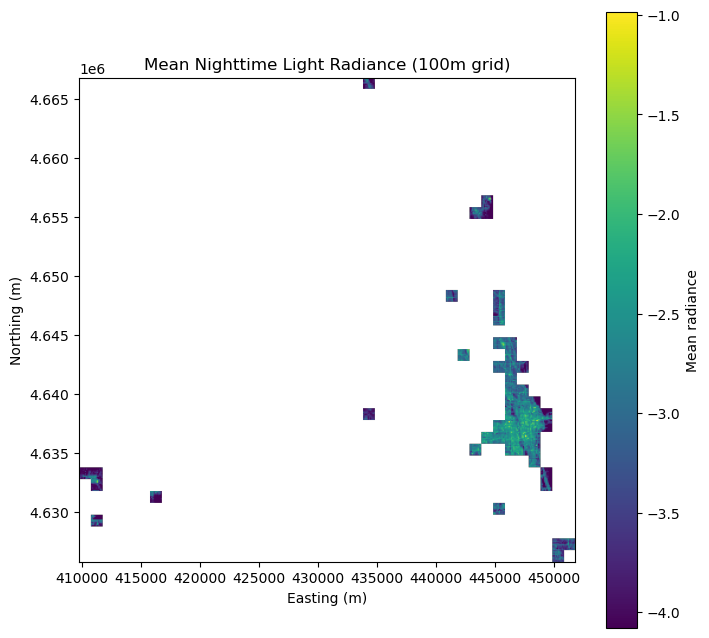

In [ ]:
# plot
raster_path = "../data/processed/grid_100m_ntl_mean.tif"

with rio.open(raster_path) as src:
    data = src.read(1)
    extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    )

fig, ax = plt.subplots(figsize=(8, 8))

img = ax.imshow(
    data,
    extent=extent,
    origin="upper"
)

cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Mean radiance")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Mean Nighttime Light Radiance (100m grid)")
ax.set_aspect("equal")

plt.show()

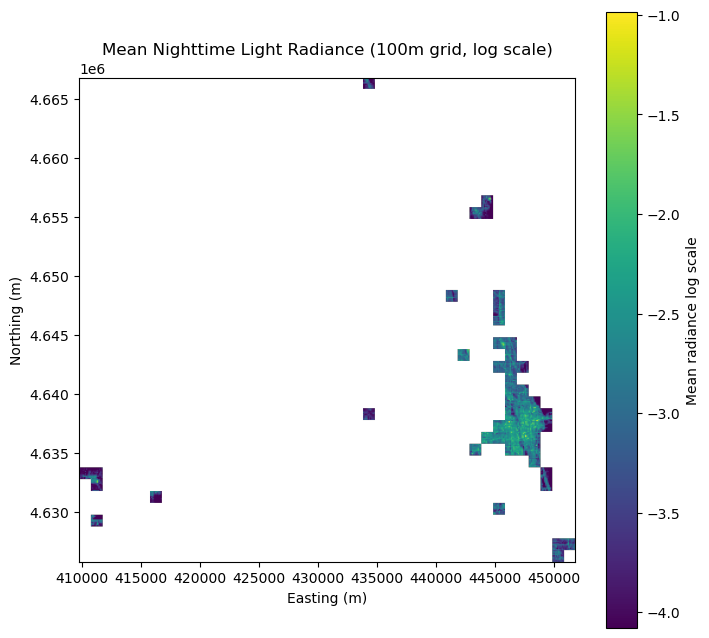

In [ ]:
# log scale
# plot
raster_path = "../data/processed/grid_100m_ntl_mean_log10.tif"

with rio.open(raster_path) as src:
    data = src.read(1)
    extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    )

fig, ax = plt.subplots(figsize=(8, 8))

img = ax.imshow(
    data,
    extent=extent,
    origin="upper"
)

cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Mean radiance log scale")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Mean Nighttime Light Radiance (100m grid, log scale)")
ax.set_aspect("equal")

plt.show()

### Compute multi-resolution NTL (100m grid, moving window)

Note: this grid_100m is the same as the one used in the "calculate ntl to 100m grids" section, representing the 100m fishnet within density-dependent boundaries

In [ ]:
# path
# ntl_path = os.path.join(out_path, "ntl_band3_26916_radiance.tif") # linear scale

ntl_path = os.path.join(out_path, "ntl_band3_26916_radiance_log10.tif") # log scale

In [ ]:
# # check first band of ntl
# rio.open(ntl_path).read()[0]

with rio.open(ntl_path) as src:
    
    # read all bands (shape: [bands, rows, cols])
    data = src.read()
    
    # get first band using [0]
    band1 = data[0]
    
    print("Shape:", data.shape)
    print("Band 1 shape:", band1.shape)
    print("Nodata:", src.nodata)
    
    # basic stats
    print("\n--- Band 1 stats ---")
    print("Min:", np.nanmin(band1))
    print("Max:", np.nanmax(band1))
    print("Mean:", np.nanmean(band1))

Shape: (1, 37272, 22376)
Band 1 shape: (37272, 22376)
Nodata: None

--- Band 1 stats ---
Min: -4.7548513
Max: -0.56888115
Mean: -4.269321


In [ ]:
# compute centroids of 100m grids
grid_100m["centroid"] = grid_100m.geometry.centroid

# create 500m x 500m squares centered at centroid
grid_100m["geom_500m"] = grid_100m["centroid"].buffer(250, cap_style=3)

# create 1000m x 1000m squares centered at centroid
grid_100m["geom_1000m"] = grid_100m["centroid"].buffer(500, cap_style=3)

In [ ]:
print("Number of 100m grids:", len(grid_100m))
print("Number of 500m squares:", len(grid_100m["geom_500m"]))
print("Number of 1000m squares:", len(grid_100m["geom_1000m"]))

Number of 100m grids: 5200
Number of 500m squares: 5200
Number of 1000m squares: 5200


In [ ]:
# # check area
# print("500m area stats:")
# print(grid_100m["area_500m"].describe())

# print("\n1000m area stats:")
# print(grid_100m["area_1000m"].describe())

In [ ]:
def zonal_mean_raster(poly, src):
    # mask raster by polygon
    out_image, _ = mask(src, [poly], crop=True)
    
    # extract first band
    arr = out_image[0]
    
    # remove nodata values
    arr = arr[arr != src.nodata]
    
    # return mean value
    return arr.mean()

In [ ]:
with rio.open(ntl_path) as src:
    
    # compute mean NTL within 500m x 500m window
    grid_100m["ntl_mean_500m"] = grid_100m["geom_500m"].apply(
        lambda g: zonal_mean_raster(g, src)
    )
    
    # compute mean NTL within 1000m x 1000m window
    grid_100m["ntl_mean_1000m"] = grid_100m["geom_1000m"].apply(
        lambda g: zonal_mean_raster(g, src)
    )

In [ ]:
grid_100m

,cell_id,n_points,geometry,ntl_mean,x,y,centroid,geom_500m,geom_1000m,ntl_mean_500m,ntl_mean_1000m
0,17566,51,"POLYGON ((409892.021 4632857.241, 409892.021 4...",-3.321543,409842.021002,4.632807e+06,POINT (409842.021 4632807.241),"POLYGON ((410092.021 4633057.241, 410092.021 4...","POLYGON ((410342.021 4633307.241, 410342.021 4...",-3.747250,-3.746953
1,17566,51,"POLYGON ((409892.021 4632957.241, 409892.021 4...",-3.970497,409842.021002,4.632907e+06,POINT (409842.021 4632907.241),"POLYGON ((410092.021 4633157.241, 410092.021 4...","POLYGON ((410342.021 4633407.241, 410342.021 4...",-3.726699,-3.755049
2,17566,51,"POLYGON ((409892.021 4633057.241, 409892.021 4...",-4.073375,409842.021002,4.633007e+06,POINT (409842.021 4633007.241),"POLYGON ((410092.021 4633257.241, 410092.021 4...","POLYGON ((410342.021 4633507.241, 410342.021 4...",-3.743849,-3.784079
3,17566,51,"POLYGON ((409892.021 4633157.241, 409892.021 4...",-3.979088,409842.021002,4.633107e+06,POINT (409842.021 4633107.241),"POLYGON ((410092.021 4633357.241, 410092.021 4...","POLYGON ((410342.021 4633607.241, 410342.021 4...",-3.771164,-3.799911
4,17566,51,"POLYGON ((409892.021 4633257.241, 409892.021 4...",-3.940451,409842.021002,4.633207e+06,POINT (409842.021 4633207.241),"POLYGON ((410092.021 4633457.241, 410092.021 4...","POLYGON ((410342.021 4633707.241, 410342.021 4...",-3.795545,-3.828061
...,...,...,...,...,...,...,...,...,...,...,...
5195,26744,77,"POLYGON ((451792.021 4627257.241, 451692.021 4...",-3.293381,451742.021002,4.627307e+06,POINT (451742.021 4627307.241),"POLYGON ((451992.021 4627557.241, 451992.021 4...","POLYGON ((452242.021 4627807.241, 452242.021 4...",-3.262097,-3.460850
5196,26744,77,"POLYGON ((451792.021 4627357.241, 451692.021 4...",-3.000813,451742.021002,4.627407e+06,POINT (451742.021 4627407.241),"POLYGON ((451992.021 4627657.241, 451992.021 4...","POLYGON ((452242.021 4627907.241, 452242.021 4...",-3.334175,-3.478015
5197,26744,77,"POLYGON ((451792.021 4627457.241, 451692.021 4...",-3.182234,451742.021002,4.627507e+06,POINT (451742.021 4627507.241),"POLYGON ((451992.021 4627757.241, 451992.021 4...","POLYGON ((452242.021 4628007.241, 452242.021 4...",-3.435928,-3.506625
5198,26744,77,"POLYGON ((451792.021 4627557.241, 451692.021 4...",-3.227192,451742.021002,4.627607e+06,POINT (451742.021 4627607.241),"POLYGON ((451992.021 4627857.241, 451992.021 4...","POLYGON ((452242.021 4628107.241, 452242.021 4...",-3.496833,-3.526809


In [ ]:
# save as raster - prep
# extract centroid coordinates
grid_100m["x"] = grid_100m.geometry.centroid.x
grid_100m["y"] = grid_100m.geometry.centroid.y

cell_size = 100

# raster extent
minx, miny, maxx, maxy = grid_100m.total_bounds

width = int((maxx - minx) / cell_size)
height = int((maxy - miny) / cell_size)

transform = from_origin(minx, maxy, cell_size, cell_size)

In [ ]:
# save 500m grid raster
out_raster_500 = "../data/processed/grid_100m_ntl_mean_log10_500m.tif"

# create empty raster
raster_array_500 = np.full((height, width), np.nan, dtype="float32")

# fill values
for _, row in grid_100m.iterrows():
    col = int((row["x"] - minx) / cell_size)
    row_idx = int((maxy - row["y"]) / cell_size)
    raster_array_500[row_idx, col] = row["ntl_mean_500m"]

# write GeoTIFF
with rio.open(
    out_raster_500,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=grid_100m.crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(raster_array_500, 1)

print("Saved:", out_raster_500)

Saved: ../data/processed/grid_100m_ntl_mean_log10_500m.tif


In [ ]:
# save 1000m grid raster
out_raster_1000 = "../data/processed/grid_100m_ntl_mean_log10_1000m.tif"

# create empty raster
raster_array_1000 = np.full((height, width), np.nan, dtype="float32")

# fill values
for _, row in grid_100m.iterrows():
    col = int((row["x"] - minx) / cell_size)
    row_idx = int((maxy - row["y"]) / cell_size)
    raster_array_1000[row_idx, col] = row["ntl_mean_1000m"]

# write GeoTIFF
with rio.open(
    out_raster_1000,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=grid_100m.crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(raster_array_1000, 1)

print("Saved:", out_raster_1000)

Saved: ../data/processed/grid_100m_ntl_mean_log10_1000m.tif


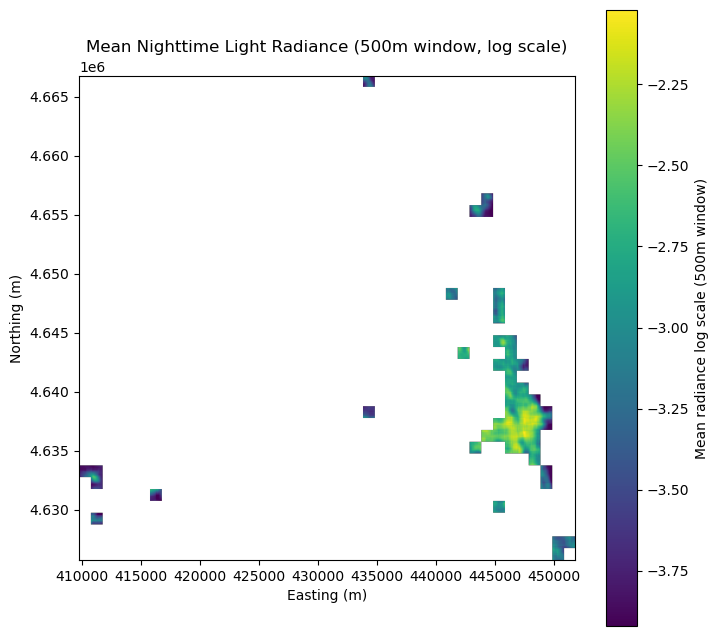

In [ ]:
# plot 500m
raster_path_500 = "../data/processed/grid_100m_ntl_mean_log10_500m.tif"

with rio.open(raster_path_500) as src:
    data = src.read(1)
    extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    )

fig, ax = plt.subplots(figsize=(8, 8))

img = ax.imshow(
    data,
    extent=extent,
    origin="upper"
)

cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Mean radiance log scale (500m window)")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Mean Nighttime Light Radiance (500m window, log scale)")
ax.set_aspect("equal")

plt.show()

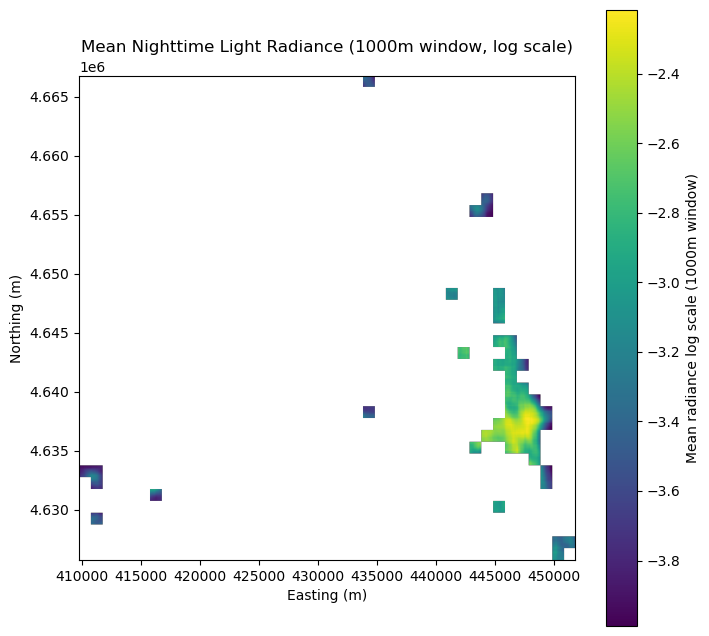

In [ ]:
# plot 1000m
raster_path_1000 = "../data/processed/grid_100m_ntl_mean_log10_1000m.tif"

with rio.open(raster_path_1000) as src:
    data = src.read(1)
    extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    )

fig, ax = plt.subplots(figsize=(8, 8))

img = ax.imshow(
    data,
    extent=extent,
    origin="upper"
)

cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Mean radiance log scale (1000m window)")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Mean Nighttime Light Radiance (1000m window, log scale)")
ax.set_aspect("equal")

plt.show()

### Check correlation among different ntl

In [ ]:
# raster paths
path_raster = "../data/processed"

f_100 = os.path.join(path_raster, "grid_100m_ntl_mean_log10.tif")
f_500 = os.path.join(path_raster, "grid_100m_ntl_mean_log10_500m.tif")
f_1000 = os.path.join(path_raster, "grid_100m_ntl_mean_log10_1000m.tif")

In [ ]:
# make sure boundary CRS matches raster CRS
with rio.open(f_100) as src:
    raster_crs = src.crs

study_boundary = grid_filtered.to_crs(raster_crs)

In [ ]:
# merge all polygons into one boundary
study_union = study_boundary.union_all()
study_geom = [study_union.__geo_interface__]

In [ ]:
# crop and mask raster by study boundary
with rio.open(f_100) as src:
    arr_100, _ = mask(src, study_geom, crop=True)
    nodata_100 = src.nodata

with rio.open(f_500) as src:
    arr_500, _ = mask(src, study_geom, crop=True)
    nodata_500 = src.nodata

with rio.open(f_1000) as src:
    arr_1000, _ = mask(src, study_geom, crop=True)
    nodata_1000 = src.nodata

In [ ]:
# take the first band
arr_100 = arr_100[0].astype(float)
arr_500 = arr_500[0].astype(float)
arr_1000 = arr_1000[0].astype(float)

In [ ]:
# keep only cells valid in all three rasters
valid = (
    ~np.isnan(arr_100) &
    ~np.isnan(arr_500) &
    ~np.isnan(arr_1000)
)

vals_100 = arr_100[valid]
vals_500 = arr_500[valid]
vals_1000 = arr_1000[valid]

In [ ]:
# build dataframe
df_ntl = pd.DataFrame({
    "ntl_100m": vals_100,
    "ntl_500m": vals_500,
    "ntl_1000m": vals_1000
})

df_ntl.head()

,ntl_100m,ntl_500m,ntl_1000m
0,-2.726367,-2.988389,-3.250798
1,-2.454303,-2.885319,-3.277624
2,-2.775812,-2.938991,-3.311613
3,-3.107060,-3.135203,-3.379284
4,-3.949086,-3.386628,-3.446905


In [ ]:
# correlation matrix
corr = df_ntl.corr(method="pearson")
corr

,ntl_100m,ntl_500m,ntl_1000m
ntl_100m,1.000000,0.866543,0.803964
ntl_500m,0.866543,1.000000,0.958608
ntl_1000m,0.803964,0.958608,1.000000


### Compute multi-resolution building density (100m grid, moving window)


Note: Building density is calculated as the mean value of `grid_100m_building_cover.tif` inside centered 500m x 500m and 1000m x 1000m square windows.


In [10]:
# path
building_path = os.path.join(path_env, "grid_100m_building_cover.tif")

# output paths
out_building_500 = os.path.join(out_path, "grid_100m_building_density_500m.tif")
out_building_1000 = os.path.join(out_path, "grid_100m_building_density_1000m.tif")


In [11]:
# check first band of building cover raster
with rio.open(building_path) as src:
    nodata = src.nodata

    print("Shape:", (src.height, src.width))
    print("CRS:", src.crs)
    print("Nodata:", nodata)
    print("Resolution:", src.res)

    min_val = np.inf
    max_val = -np.inf
    total_sum = 0.0
    total_count = 0

    # read one internal block/window at a time
    for _, window in src.block_windows(1):
        block = src.read(1, window=window, masked=True)
        vals = block.compressed().astype("float64")  # drops nodata/masked pixels

        if vals.size == 0:
            continue

        min_val = min(min_val, vals.min())
        max_val = max(max_val, vals.max())
        total_sum += vals.sum()
        total_count += vals.size

    print("\n--- Building cover stats ---")
    print("Min:", min_val)
    print("Max:", max_val)
    print("Mean:", total_sum / total_count if total_count > 0 else np.nan)
    print("Valid pixel count:", total_count)

Shape: (304134, 245735)
CRS: EPSG:26916
Nodata: None
Resolution: (0.3048006096012192, 0.3048006096012196)

--- Building cover stats ---
Min: 0.0
Max: 1.0
Mean: 0.08506382420802558
Valid pixel count: 74736368490


In [12]:
# # make sure grid CRS matches the building raster CRS before creating meter-based windows
with rio.open(building_path) as src:
    building_crs = src.crs

building_grid_100m = grid_100m.to_crs(building_crs).copy()

# compute centroids of 100m grids
building_grid_100m["centroid"] = building_grid_100m.geometry.centroid

# create 500m x 500m squares centered at centroid
building_grid_100m["geom_500m"] = building_grid_100m["centroid"].buffer(250, cap_style=3)

# create 1000m x 1000m squares centered at centroid
building_grid_100m["geom_1000m"] = building_grid_100m["centroid"].buffer(500, cap_style=3)

print("Number of 100m grids:", len(building_grid_100m))
print("Number of 500m squares:", len(building_grid_100m["geom_500m"]))
print("Number of 1000m squares:", len(building_grid_100m["geom_1000m"]))


Number of 100m grids: 5200
Number of 500m squares: 5200
Number of 1000m squares: 5200


In [13]:
def zonal_mean_raster_nan(poly, src):
    # mask raster by polygon
    out_image, _ = mask(src, [poly], crop=True)

    # extract first band
    arr = out_image[0].astype("float32")

    # remove nodata values
    if src.nodata is not None:
        arr = np.where(arr == src.nodata, np.nan, arr)

    # return mean value
    if np.all(np.isnan(arr)):
        return np.nan

    return np.nanmean(arr)


In [14]:
with rio.open(building_path) as src:

    # compute mean building density within 500m x 500m window
    building_grid_100m["building_density_500m"] = building_grid_100m["geom_500m"].apply(
        lambda g: zonal_mean_raster_nan(g, src)
    )

    # compute mean building density within 1000m x 1000m window
    building_grid_100m["building_density_1000m"] = building_grid_100m["geom_1000m"].apply(
        lambda g: zonal_mean_raster_nan(g, src)
    )

building_grid_100m[["building_density_500m", "building_density_1000m"]].describe()


,building_density_500m,building_density_1000m
count,5200.000000,5200.000000
mean,0.266112,0.261726
std,0.148751,0.128146
min,0.000000,0.000000
25%,0.149129,0.159495
50%,0.285667,0.279804
75%,0.390781,0.361900
max,0.656991,0.529995


In [15]:
# save as raster - prep
# extract centroid coordinates
building_grid_100m["x"] = building_grid_100m.geometry.centroid.x
building_grid_100m["y"] = building_grid_100m.geometry.centroid.y

cell_size = 100

# raster extent
minx, miny, maxx, maxy = building_grid_100m.total_bounds

width = int((maxx - minx) / cell_size)
height = int((maxy - miny) / cell_size)

transform = from_origin(minx, maxy, cell_size, cell_size)


In [16]:
# save 500m building density raster
raster_array_building_500 = np.full((height, width), np.nan, dtype="float32")

# fill values
for _, row in building_grid_100m.iterrows():
    col = int((row["x"] - minx) / cell_size)
    row_idx = int((maxy - row["y"]) / cell_size)
    raster_array_building_500[row_idx, col] = row["building_density_500m"]

# write GeoTIFF
with rio.open(
    out_building_500,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=building_grid_100m.crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(raster_array_building_500, 1)

print("Saved:", out_building_500)


Saved: ../data/processed/grid_100m_building_density_500m.tif


In [17]:
# save 1000m building density raster
raster_array_building_1000 = np.full((height, width), np.nan, dtype="float32")

# fill values
for _, row in building_grid_100m.iterrows():
    col = int((row["x"] - minx) / cell_size)
    row_idx = int((maxy - row["y"]) / cell_size)
    raster_array_building_1000[row_idx, col] = row["building_density_1000m"]

# write GeoTIFF
with rio.open(
    out_building_1000,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=building_grid_100m.crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(raster_array_building_1000, 1)

print("Saved:", out_building_1000)


Saved: ../data/processed/grid_100m_building_density_1000m.tif


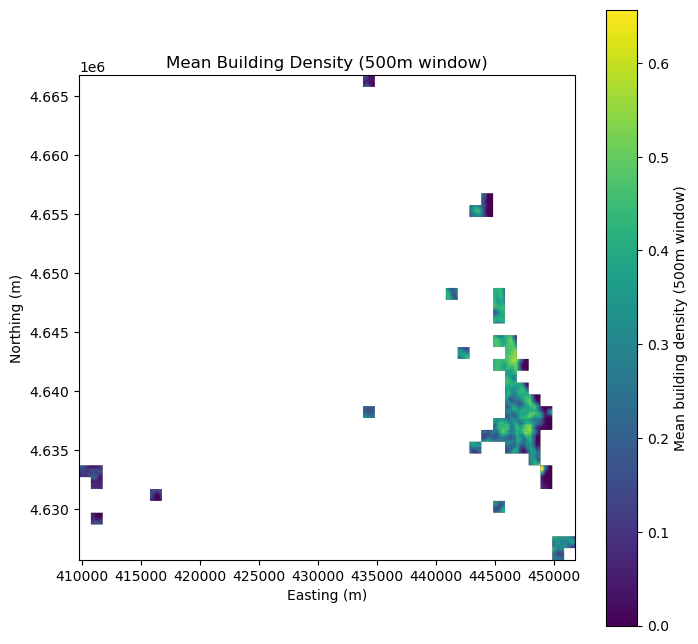

In [18]:
# plot 500m building density
with rio.open(out_building_500) as src:
    data = src.read(1)
    extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    )

fig, ax = plt.subplots(figsize=(8, 8))

img = ax.imshow(
    data,
    extent=extent,
    origin="upper"
)

cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Mean building density (500m window)")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Mean Building Density (500m window)")
ax.set_aspect("equal")

plt.show()


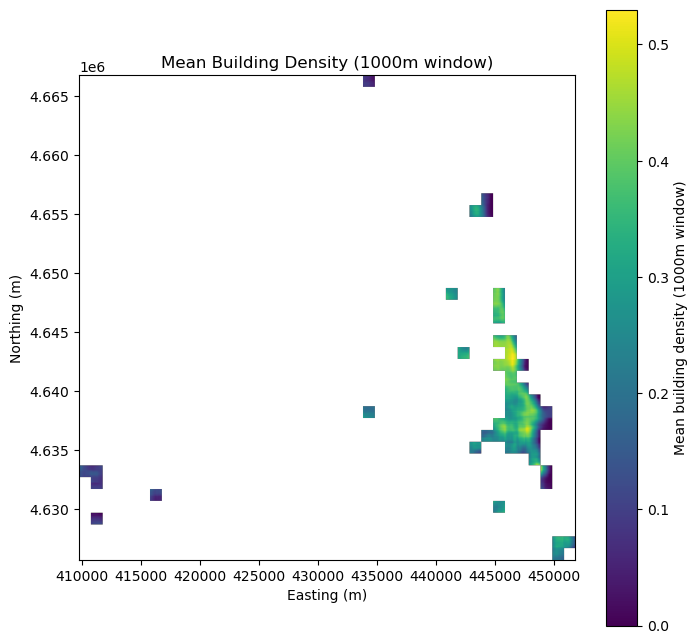

In [19]:
# plot 1000m building density
with rio.open(out_building_1000) as src:
    data = src.read(1)
    extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    )

fig, ax = plt.subplots(figsize=(8, 8))

img = ax.imshow(
    data,
    extent=extent,
    origin="upper"
)

cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Mean building density (1000m window)")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Mean Building Density (1000m window)")
ax.set_aspect("equal")

plt.show()


In [20]:
# Check correlation among different building density windows
# raster paths
path_raster = "../data/processed"

f_building_100 = building_path
f_building_500 = os.path.join(path_raster, "grid_100m_building_density_500m.tif")
f_building_1000 = os.path.join(path_raster, "grid_100m_building_density_1000m.tif")


In [ ]:
# make sure boundary CRS matches raster CRS
with rio.open(f_building_100) as src:
    raster_crs = src.crs

study_boundary_building = grid_filtered.to_crs(raster_crs)

# merge all polygons into one boundary
study_union_building = study_boundary_building.union_all()
study_geom_building = [study_union_building.__geo_interface__]


: 

In [ ]:
# crop and mask raster by study boundary
with rio.open(f_building_100) as src:
    arr_building_100, _ = mask(src, study_geom_building, crop=True)

with rio.open(f_building_500) as src:
    arr_building_500, _ = mask(src, study_geom_building, crop=True)

with rio.open(f_building_1000) as src:
    arr_building_1000, _ = mask(src, study_geom_building, crop=True)


In [ ]:
# take the first band
arr_building_100 = arr_building_100[0].astype(float)
arr_building_500 = arr_building_500[0].astype(float)
arr_building_1000 = arr_building_1000[0].astype(float)


In [ ]:
# keep only cells valid in all three rasters
valid_building = (
    ~np.isnan(arr_building_100) &
    ~np.isnan(arr_building_500) &
    ~np.isnan(arr_building_1000)
)

vals_building_100 = arr_building_100[valid_building]
vals_building_500 = arr_building_500[valid_building]
vals_building_1000 = arr_building_1000[valid_building]


In [ ]:
# build dataframe
df_building_density = pd.DataFrame({
    "building_density_100m": vals_building_100,
    "building_density_500m": vals_building_500,
    "building_density_1000m": vals_building_1000
})

df_building_density.head()


In [ ]:
# correlation matrix
corr_building_density = df_building_density.corr(method="pearson")
corr_building_density
